# Day 01: How LLMs Generate Text — A Platform Engineer’s Guide
> *100 Days of Inference* | Based on *Inference Engineering* Ch 2.2 (Philip Kiely) + DeepLearning.AI “Efficiently Serving LLMs”

**Who this is for:** Engineers from a Platform / DevOps / SRE background who are new to ML.
Every concept maps to something you already know — caching, serialization, capacity planning, queue theory.

**Layer:** Runtime

**Topics:** Tokenization, Prefill/Decode phases, KV Cache, Autoregressive decoding, Sampling strategies

**Time:** ~30–45 minutes interactive

## The Big Picture: What Is an LLM Doing When It Responds to You?

Think of an LLM as a **weird HTTP server** with one rule:

> It can only write **one word at a time**, and each new word is determined by everything it has written so far.

That’s it. There is no “thinking” happening upfront. The model does not plan a 500-word response
and then stream it. It literally picks the next token, appends it to the context, and repeats.

This notebook breaks that loop into its parts:

| Part | What it does | Infra analogy |
|---|---|---|
| **Tokenizer** | Converts text ↔ integers | Protocol serializer (protobuf, JSON codec) |
| **Prefill** | Processes your input prompt in one parallel pass | Init container / cold start |
| **KV Cache** | Stores intermediate state so decode is fast | Redis — memoization layer |
| **Decode loop** | Generates one token per step, autoregressively | Event loop draining a queue |
| **Sampling** | Picks the next token from a probability distribution | Weighted load balancer |

In [14]:
# Setup -- install deps and configure plotting
!pip install -q numpy torch matplotlib transformers

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import math
import random

try:
    import torch
    TORCH_AVAILABLE = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"PyTorch {torch.__version__} | device: {DEVICE}")
    if DEVICE == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("Running on CPU -- timings will be slower than a GPU deployment")
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = "cpu"
    print("PyTorch not available -- numpy-only mode")

# Dark theme for charts
plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",   "text.color": "#e6edf3",
    "axes.labelcolor": "#e6edf3",  "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",      "grid.color": "#21262d",
})
%matplotlib inline

PyTorch 2.11.0+cu130 | device: cuda
GPU: NVIDIA GB10
VRAM: 128.5 GB


## Part 1: Tokenization — Converting Text to Numbers

### The DevOps Analogy

A **tokenizer** is like a **protocol serializer** — the same job as protobuf, MessagePack, or JSON encoding.

- Your text goes in as a human-readable string
- A compact integer representation comes out
- The mapping is fixed at build time (the vocabulary), not learned at runtime
- No neural network is involved — it’s a deterministic lookup table

Modern LLMs use **subword tokenization**: common words get a single token, rare words
are split into pieces. This is exactly like variable-length encoding in compression.

Key facts from the book:
- Most models have vocabularies of 100,000+ tokens
- Fewer tokens per input = fewer decode steps = lower latency
- The tokenizer is model-specific — each model family has its own vocabulary

*Book Figure 2.5 shows the sentence “Inference engineering makes AI apps fast.” tokenized
into 8 subword tokens with their corresponding integer IDs.*

In [15]:
# Build a toy tokenizer from scratch to show the mechanics
# Real tokenizers (GPT-2, Llama-3) do exactly this but with 50k-128k vocabulary entries

# Vocabulary = the lookup table: word -> integer ID
VOCAB = {
    "<pad>": 0, "<bos>": 1, "<eos>": 2, "<unk>": 3,  # special control tokens
    # Common words/subwords -- each maps to a unique integer
    "In": 644, "\u2581ference": 2251, "\u2581engineering": 15009,
    "\u2581makes": 3727, "\u2581AI": 15592, "\u2581apps": 10721,
    "\u2581fast": 5043, ".": 13,
    "\u2581inference": 100, "\u2581is": 200, "\u2581slow": 300,
    "\u2581without": 400, "\u2581KV": 500, "\u2581cache": 600,
    "\u2581The": 700, "\u2581model": 800, "\u2581generates": 900,
    "\u2581tokens": 1000, "\u2581one": 1100, "\u2581at": 1200,
    "\u2581a": 1300, "\u2581time": 1400,
}
ID_TO_TOKEN = {v: k for k, v in VOCAB.items()}

def tokenize(text: str) -> list[int]:
    """Convert text to a list of integer token IDs."""
    tokens = []
    words = text.split()
    for i, word in enumerate(words):
        key = ("\u2581" + word) if i > 0 else word  # \u2581 marks a space before the word
        tok_id = VOCAB.get(key, VOCAB.get(word, VOCAB["<unk>"]))
        tokens.append(tok_id)
    return tokens

def detokenize(token_ids: list[int]) -> str:
    """Convert integer IDs back to text."""
    return " ".join(ID_TO_TOKEN.get(tid, "<unk>").lstrip("\u2581") for tid in token_ids)

sentence  = "Inference engineering makes AI apps fast ."
token_ids = tokenize(sentence)

print(f"Input text :  '{sentence}'")
print(f"Token IDs  :  {token_ids}")
print(f"Decoded    :  '{detokenize(token_ids)}'")
print(f"\nThis sentence = {len(token_ids)} tokens")
print(f"Real LLMs have vocabularies of 32k-200k tokens")
print(f"\nBreakdown:")
for i, tok_id in enumerate(token_ids):
    word = sentence.split()[i]
    token_str = ID_TO_TOKEN[tok_id]
    print(f"  '{word:15s}'  ->  ID {tok_id:6d}  (stored as: '{token_str}')")

Input text :  'Inference engineering makes AI apps fast .'
Token IDs  :  [3, 15009, 3727, 15592, 10721, 5043, 13]
Decoded    :  '<unk> engineering makes AI apps fast .'

This sentence = 7 tokens
Real LLMs have vocabularies of 32k-200k tokens

Breakdown:
  'Inference      '  ->  ID      3  (stored as: '<unk>')
  'engineering    '  ->  ID  15009  (stored as: '▁engineering')
  'makes          '  ->  ID   3727  (stored as: '▁makes')
  'AI             '  ->  ID  15592  (stored as: '▁AI')
  'apps           '  ->  ID  10721  (stored as: '▁apps')
  'fast           '  ->  ID   5043  (stored as: '▁fast')
  '.              '  ->  ID     13  (stored as: '.')


### Token Efficiency: Why Vocabulary Size Matters

An LLM with a **larger vocabulary** can represent common phrases as a single token instead of several.
The chart below shows the same phrases tokenized two ways: a larger-vocabulary (efficient) tokenizer
vs a smaller-vocabulary (inefficient) one.

*Why this matters for inference:* each token = one decode step = one GPU forward pass.
Fewer tokens = fewer passes = lower latency and cost.

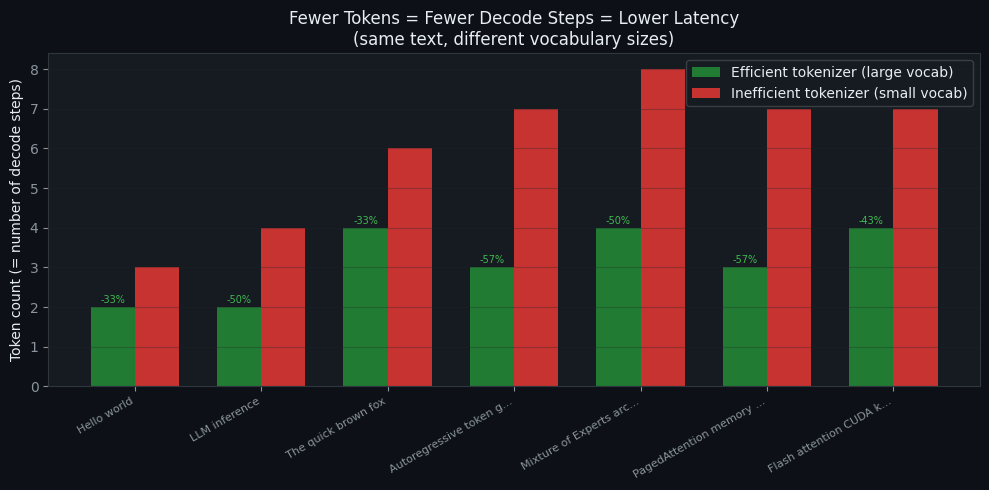

Average token reduction: 46.3% -> that is 46.3% fewer GPU cycles for free


In [16]:
# Same phrases, two different tokenizers -- shows why vocabulary size = performance
EXAMPLES = [
    ("Hello world",                        2,  3),
    ("LLM inference",                      2,  4),
    ("The quick brown fox",                4,  6),
    ("Autoregressive token generation",    3,  7),
    ("Mixture of Experts architecture",    4,  8),
    ("PagedAttention memory management",   3,  7),
    ("Flash attention CUDA kernel",        4,  7),
]
# Column: (phrase, efficient_tokenizer_count, inefficient_tokenizer_count)

texts       = [e[0] for e in EXAMPLES]
efficient   = [e[1] for e in EXAMPLES]
inefficient = [e[2] for e in EXAMPLES]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(texts))
w = 0.35

ax.bar(x - w/2, efficient,   w, label="Efficient tokenizer (large vocab)",   color="#238636", alpha=0.9)
ax.bar(x + w/2, inefficient, w, label="Inefficient tokenizer (small vocab)", color="#da3633", alpha=0.9)

ax.set_ylabel("Token count (= number of decode steps)", color="#e6edf3")
ax.set_title("Fewer Tokens = Fewer Decode Steps = Lower Latency\n(same text, different vocabulary sizes)",
             color="#e6edf3", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([t[:22] + "..." if len(t) > 22 else t for t in texts], rotation=30, ha="right", fontsize=8)
ax.legend(framealpha=0.2)
ax.grid(axis="y", alpha=0.3)

for i, (eff, ineff) in enumerate(zip(efficient, inefficient)):
    savings = (ineff - eff) / ineff * 100
    ax.annotate(f"-{savings:.0f}%", xy=(i - w/2, eff + 0.05),
                ha="center", va="bottom", fontsize=7, color="#3fb950")

plt.tight_layout()
plt.show()
avg = np.mean([(i - e) / i * 100 for e, i in zip(efficient, inefficient)])
print(f"Average token reduction: {avg:.1f}% -> that is {avg:.1f}% fewer GPU cycles for free")

## Part 2: The Two Phases of LLM Inference — Prefill and Decode

### The DevOps Analogy

Think of an LLM serving request like a **two-phase Kubernetes pod startup**:

| Phase | Analogy | What happens |
|---|---|---|
| **Prefill** | Cold start / init container | All your input tokens are processed *in parallel* to build the KV cache |
| **Decode** | Main container serving requests | Output tokens are generated *one at a time*, each reading from the cache |

The two key latency metrics map directly:
- **TTFT (Time To First Token)** = how long until the init container is ready = prefill duration
- **TPOT (Time Per Output Token)** = per-request latency in steady state = decode step duration

**The bottleneck is different for each phase:**
- Prefill is **compute-bound** (lots of matrix multiplications, GPU cores are the bottleneck)
- Decode is **memory-bandwidth-bound** (reading the KV cache from GPU HBM is the bottleneck)

This distinction matters for hardware selection: more FLOPS helps prefill, more memory bandwidth helps decode.

Scenario                                Prefill     Decode      Total       TTFT
--------------------------------------------------------------------------------
Short prompt + short output                64ms      960ms     1024ms       64ms
Long prompt  + short output              2048ms      960ms     3008ms     2048ms
Short prompt + long output                 64ms     7680ms     7744ms       64ms
Long prompt  + long output               2048ms     7680ms     9728ms     2048ms


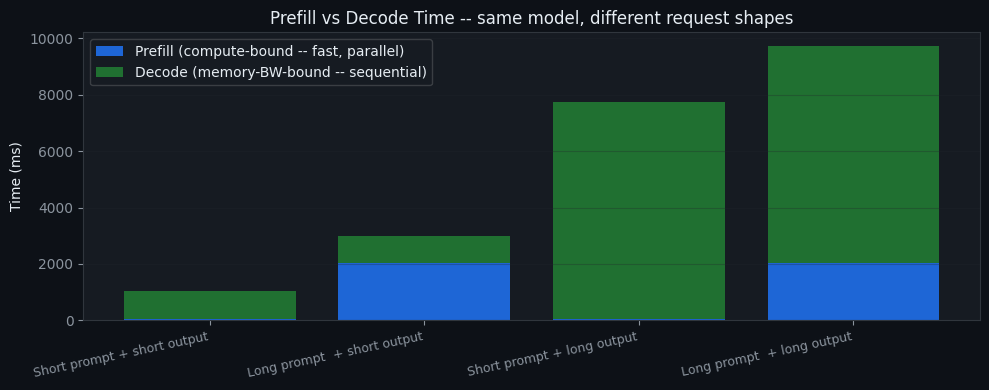


Key insight: long outputs are dominated by decode time.
Adding more compute (GPUs) helps prefill but barely helps decode.
Decode needs memory bandwidth -- that is why H100s 3.35 TB/s HBM matters.


In [17]:
# Simulate the prefill vs decode time breakdown for different request shapes
# These numbers are representative of a mid-size model on a single GPU

def simulate_request(
    prompt_tokens: int,
    output_tokens: int,
    prefill_ms_per_token: float = 0.5,    # fast: all tokens processed in parallel
    decode_ms_per_token: float = 15.0,    # slower: one at a time + memory reads
):
    prefill_ms = prompt_tokens * prefill_ms_per_token
    decode_ms  = output_tokens * decode_ms_per_token
    return {
        "prefill_ms": prefill_ms,
        "decode_ms":  decode_ms,
        "total_ms":   prefill_ms + decode_ms,
        "ttft_ms":    prefill_ms,               # Time To First Token
        "tpot_ms":    decode_ms_per_token,      # Time Per Output Token
    }

scenarios = [
    ("Short prompt + short output",  128,   64),
    ("Long prompt  + short output",  4096,  64),
    ("Short prompt + long output",   128,   512),
    ("Long prompt  + long output",   4096,  512),
]

print(f"{'Scenario':<36} {'Prefill':>10} {'Decode':>10} {'Total':>10} {'TTFT':>10}")
print("-" * 80)
for name, p, o in scenarios:
    r = simulate_request(p, o)
    print(f"{name:<36} {r['prefill_ms']:>8.0f}ms {r['decode_ms']:>8.0f}ms "
          f"{r['total_ms']:>8.0f}ms {r['ttft_ms']:>8.0f}ms")

fig, ax = plt.subplots(figsize=(10, 4))
names    = [s[0] for s in scenarios]
results  = [simulate_request(s[1], s[2]) for s in scenarios]
prefills = [r["prefill_ms"] for r in results]
decodes  = [r["decode_ms"]  for r in results]
x = np.arange(len(names))

ax.bar(x, prefills, label="Prefill (compute-bound -- fast, parallel)",       color="#1f6feb", alpha=0.9)
ax.bar(x, decodes, bottom=prefills, label="Decode (memory-BW-bound -- sequential)", color="#238636", alpha=0.8)
ax.set_ylabel("Time (ms)", color="#e6edf3")
ax.set_title("Prefill vs Decode Time -- same model, different request shapes", color="#e6edf3", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=12, ha="right", fontsize=9)
ax.legend(framealpha=0.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("\nKey insight: long outputs are dominated by decode time.")
print("Adding more compute (GPUs) helps prefill but barely helps decode.")
print("Decode needs memory bandwidth -- that is why H100s 3.35 TB/s HBM matters.")

## Part 3: Attention and the KV Cache

To generate a token, the model needs to look back at every previous token and figure out
which ones are relevant right now. That process is called **attention**.

The easiest way to understand it is to run it. The next cell builds attention from scratch
with plain numpy — no ML libraries, no magic.

In [18]:
# Attention from scratch -- think of it as a relevance-weighted lookup
#
# Setup: we have 5 tokens already generated. A 6th token arrives.
# It needs to decide: which of the 5 previous tokens should influence me most?

np.random.seed(42)

# Each token gets a key ("what I have") and a value ("what I'll give you")
# The new token gets a query ("what I'm looking for")
# These are just vectors of numbers -- the model learns what to put in them during training

d = 4  # keep dimensions tiny so we can print everything
tokens = ["The", "server", "crashed", "due", "to"]

keys   = np.random.randn(5, d).round(2)   # one key per previous token
values = np.random.randn(5, d).round(2)   # one value per previous token
query  = np.random.randn(1, d).round(2)   # the new token's query

print("=== The new token sends a query ===")
print(f"Query: {query[0]}\n")

print("=== It scores the query against every previous token's key ===")
scores = (query @ keys.T).flatten()  # dot product = similarity
for i, tok in enumerate(tokens):
    print(f"  '{tok:8s}' key={keys[i]}  score={scores[i]:+.2f}")

print(f"\n=== Convert scores to weights (softmax -- they sum to 1.0) ===")
exp_scores = np.exp(scores - scores.max())
weights = exp_scores / exp_scores.sum()
for i, tok in enumerate(tokens):
    bar = '#' * int(weights[i] * 40)
    print(f"  '{tok:8s}' weight={weights[i]:.3f}  {bar}")

print(f"\n=== Weighted sum of values = the output ===")
output = weights @ values
print(f"  Result: {output.round(3)}")
print(f"\nThis output vector is what the model uses to predict the next token.")
print(f"High-weight tokens contributed more to the result.")

=== The new token sends a query ===
Query: [ 0.74  0.17 -0.12 -0.3 ]

=== It scores the query against every previous token's key ===
  'The     ' key=[ 0.5  -0.14  0.65  1.52]  score=-0.19
  'server  ' key=[-0.23 -0.23  1.58  0.77]  score=-0.63
  'crashed ' key=[-0.47  0.54 -0.46 -0.47]  score=-0.06
  'due     ' key=[ 0.24 -1.91 -1.72 -0.56]  score=+0.23
  'to      ' key=[-1.01  0.31 -0.91 -1.41]  score=-0.16

=== Convert scores to weights (softmax -- they sum to 1.0) ===
  'The     ' weight=0.188  #######
  'server  ' weight=0.121  ####
  'crashed ' weight=0.214  ########
  'due     ' weight=0.285  ###########
  'to      ' weight=0.193  #######

=== Weighted sum of values = the output ===
  Result: [ 0.121 -0.772 -0.277 -0.135]

This output vector is what the model uses to predict the next token.
High-weight tokens contributed more to the result.


That's all attention is:

1. **Score** the new token's query against every previous token's key (dot product)
2. **Normalize** scores into weights that sum to 1 (softmax)
3. **Weighted sum** of all previous tokens' values

The expensive part: step 1 touches **every previous token**. If you have 4,000 tokens
of context, that's 4,000 dot products per decode step. And the model does this across
dozens of layers and multiple "heads" (parallel attention units).

### Why this needs a cache

Notice that the keys and values for tokens 1-5 don't change when token 6 arrives.
They were computed once during their own step and never change again.

Without caching: the model recomputes all 5 keys and values from scratch at every step.
With a **KV cache**: store them in GPU memory, only compute the new token's key and value.

The next cell shows this difference concretely.

In [19]:
# Simulate generating 8 tokens -- compare with and without KV cache
#
# Without cache: every step recomputes keys/values for ALL tokens (like re-reading the whole DB)
# With cache:    store keys/values, only compute the new one (like a cache hit)

np.random.seed(0)
N_STEPS = 8
d = 64  # realistic-ish dimension

# Pretend compute_kv() is expensive (in real models it involves matrix multiplications)
def compute_kv(token_idx, dim):
    """Simulate computing a key and value for one token."""
    return np.random.randn(dim), np.random.randn(dim)

# --- Without KV cache ---
ops_no_cache = []
for step in range(1, N_STEPS + 1):
    # Recompute keys/values for ALL tokens 0..step-1, then do attention
    kv_computations = step  # one per token in the sequence so far
    attention_lookups = step  # score query against every key
    ops_no_cache.append(kv_computations + attention_lookups)

# --- With KV cache ---
ops_with_cache = []
for step in range(1, N_STEPS + 1):
    kv_computations = 1     # only compute KV for the NEW token
    attention_lookups = step  # still need to score against all keys (can't avoid this)
    ops_with_cache.append(kv_computations + attention_lookups)

print(f"{'Step':<6} {'Without cache':<20} {'With cache':<20} {'Saved'}")
print("-" * 60)
for step in range(N_STEPS):
    saved = ops_no_cache[step] - ops_with_cache[step]
    print(f"{step+1:<6} {ops_no_cache[step]:<20} {ops_with_cache[step]:<20} {saved} ops")

total_no = sum(ops_no_cache)
total_yes = sum(ops_with_cache)
print(f"\nTotal ops:  without cache = {total_no},  with cache = {total_yes}")
print(f"Savings:    {total_no - total_yes} ops ({(total_no - total_yes)/total_no*100:.0f}%)")
print(f"\nThe savings grow with sequence length. At 1000 tokens, it's massive.")
print(f"This is why the KV cache is the #1 optimization in LLM serving.")

Step   Without cache        With cache           Saved
------------------------------------------------------------
1      2                    2                    0 ops
2      4                    3                    1 ops
3      6                    4                    2 ops
4      8                    5                    3 ops
5      10                   6                    4 ops
6      12                   7                    5 ops
7      14                   8                    6 ops
8      16                   9                    7 ops

Total ops:  without cache = 72,  with cache = 44
Savings:    28 ops (39%)

The savings grow with sequence length. At 1000 tokens, it's massive.
This is why the KV cache is the #1 optimization in LLM serving.


### The sqrt(d_k) scaling

One detail in the attention math: before softmax, the scores are divided by $\sqrt{d_k}$
(the square root of the key dimension). Why? Run this:

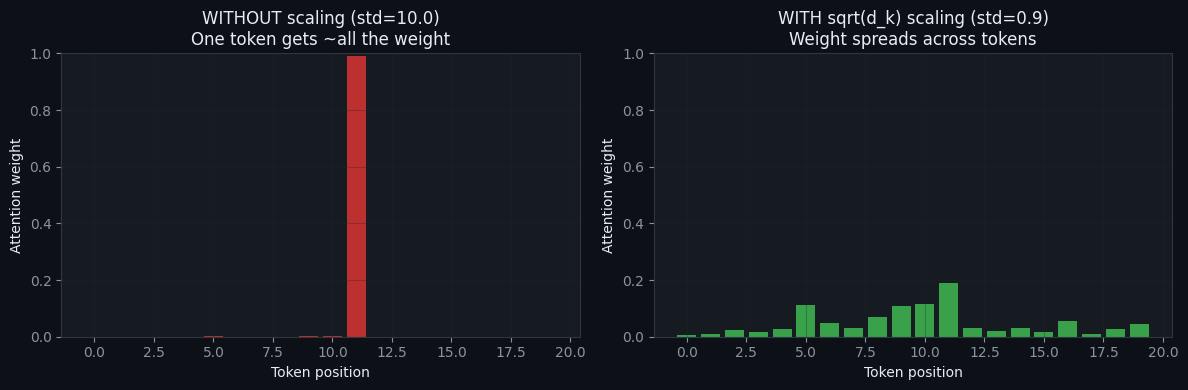

Without scaling: top token gets 99.2% of attention
With scaling:    top token gets 19.1% of attention

Scaling lets the model blend information from multiple relevant tokens.


In [20]:
# Without scaling, one token hogs all the attention weight.
# With scaling, weights spread out -- the model can attend to multiple tokens.

np.random.seed(7)
d_k = 128  # realistic key dimension
query = np.random.randn(1, d_k)
keys  = np.random.randn(20, d_k)  # 20 previous tokens

raw_scores = (query @ keys.T).flatten()
scaled_scores = raw_scores / math.sqrt(d_k)

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

weights_raw    = softmax(raw_scores)
weights_scaled = softmax(scaled_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(20), weights_raw, color='#da3633', alpha=0.85)
ax1.set_title(f'WITHOUT scaling (std={raw_scores.std():.1f})\nOne token gets ~all the weight', color='#e6edf3')
ax1.set_xlabel('Token position', color='#e6edf3')
ax1.set_ylabel('Attention weight', color='#e6edf3')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)

ax2.bar(range(20), weights_scaled, color='#3fb950', alpha=0.85)
ax2.set_title(f'WITH sqrt(d_k) scaling (std={scaled_scores.std():.1f})\nWeight spreads across tokens', color='#e6edf3')
ax2.set_xlabel('Token position', color='#e6edf3')
ax2.set_ylabel('Attention weight', color='#e6edf3')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Without scaling: top token gets {weights_raw.max():.1%} of attention")
print(f"With scaling:    top token gets {weights_scaled.max():.1%} of attention")
print(f"\nScaling lets the model blend information from multiple relevant tokens.")

### KV Cache Memory — Capacity Planning

The KV cache lives in GPU memory. How big does it get?

The formula: `2 × layers × kv_heads × head_dim × seq_len × bytes_per_value`

The 2 is for K and V (two tensors per layer per token). This is per-request —
multiply by batch size for total memory. Run the calculator:

In [21]:
# KV cache memory calculator -- same math production systems use for capacity planning

def kv_cache_memory_gb(
    num_layers: int,
    num_kv_heads: int,
    head_dim: int,
    seq_len: int,
    bytes_per_element: int = 2,   # FP16 = 2 bytes | INT8 = 1 byte | FP8 = 1 byte
    batch_size: int = 1,
) -> float:
    total = (
        2               # K tensor + V tensor
        * num_layers
        * num_kv_heads
        * head_dim
        * seq_len
        * bytes_per_element
        * batch_size
    )
    return total / 1e9

# Real model configs (approximate -- from public model cards)
MODELS = {
    'Llama-3.1-8B':   dict(num_layers=32, num_kv_heads=8,  head_dim=128),
    'Llama-3.1-70B':  dict(num_layers=80, num_kv_heads=8,  head_dim=128),
    'Qwen2.5-7B':     dict(num_layers=28, num_kv_heads=4,  head_dim=128),
    'Mistral-7B':     dict(num_layers=32, num_kv_heads=8,  head_dim=128),
    'GPT-2 (small)':  dict(num_layers=12, num_kv_heads=12, head_dim=64),
}

SEQ_LENS = [1024, 4096, 16384, 65536, 131072]

print("KV Cache Memory (GB) per batch=1 request, FP16\n")
print(f"{'Model':<22} {'1K toks':>10} {'4K toks':>10} {'16K toks':>10} {'64K toks':>10} {'128K toks':>10}")
print("-" * 75)
for name, cfg in MODELS.items():
    sizes = [kv_cache_memory_gb(**cfg, seq_len=s) for s in SEQ_LENS]
    row = f"{name:<22}" + "".join(f"{s:>9.2f}GB" for s in sizes)
    print(row)

print("\n-- Practical sizing examples --")
gb_8b_4k    = kv_cache_memory_gb(32, 8, 128, 4096)
gb_70b_128k = kv_cache_memory_gb(80, 8, 128, 131072)
print(f"Llama-3.1-8B  at 4K context:   {gb_8b_4k:.2f} GB KV cache + ~16 GB weights = {gb_8b_4k+16:.0f} GB total")
print(f"Llama-3.1-70B at 128K context: {gb_70b_128k:.1f} GB KV cache + ~140 GB weights -- needs multi-GPU")
print(f"\nGQA (Grouped Query Attention) savings:")
mha_70b = kv_cache_memory_gb(80, 64, 128, 4096)
gqa_70b = kv_cache_memory_gb(80,  8, 128, 4096)
print(f"  MHA (64 KV heads) at 4K: {mha_70b:.2f} GB  vs  GQA (8 KV heads): {gqa_70b:.2f} GB")
print(f"  GQA gives {mha_70b/gqa_70b:.0f}x smaller KV cache -- same model quality")

KV Cache Memory (GB) per batch=1 request, FP16

Model                     1K toks    4K toks   16K toks   64K toks  128K toks
---------------------------------------------------------------------------
Llama-3.1-8B               0.13GB     0.54GB     2.15GB     8.59GB    17.18GB
Llama-3.1-70B              0.34GB     1.34GB     5.37GB    21.47GB    42.95GB
Qwen2.5-7B                 0.06GB     0.23GB     0.94GB     3.76GB     7.52GB
Mistral-7B                 0.13GB     0.54GB     2.15GB     8.59GB    17.18GB
GPT-2 (small)              0.04GB     0.15GB     0.60GB     2.42GB     4.83GB

-- Practical sizing examples --
Llama-3.1-8B  at 4K context:   0.54 GB KV cache + ~16 GB weights = 17 GB total
Llama-3.1-70B at 128K context: 42.9 GB KV cache + ~140 GB weights -- needs multi-GPU

GQA (Grouped Query Attention) savings:
  MHA (64 KV heads) at 4K: 10.74 GB  vs  GQA (8 KV heads): 1.34 GB
  GQA gives 8x smaller KV cache -- same model quality


## Part 4: The Decode Loop and Sampling

Now you know the pieces. Here's how they fit into the generation loop:

```
prefill(prompt) → build KV cache

loop:
  forward_pass(new_token, kv_cache) → logits (one score per vocab word)
  apply temperature → sharpen or flatten the scores
  apply top-k / top-p → filter out unlikely candidates
  sample one token from the remaining distribution
  append its K,V to the cache
  if stop token: break
```

The next cell implements the sampling part so you can see how temperature, top-k,
and top-p change what token gets picked.

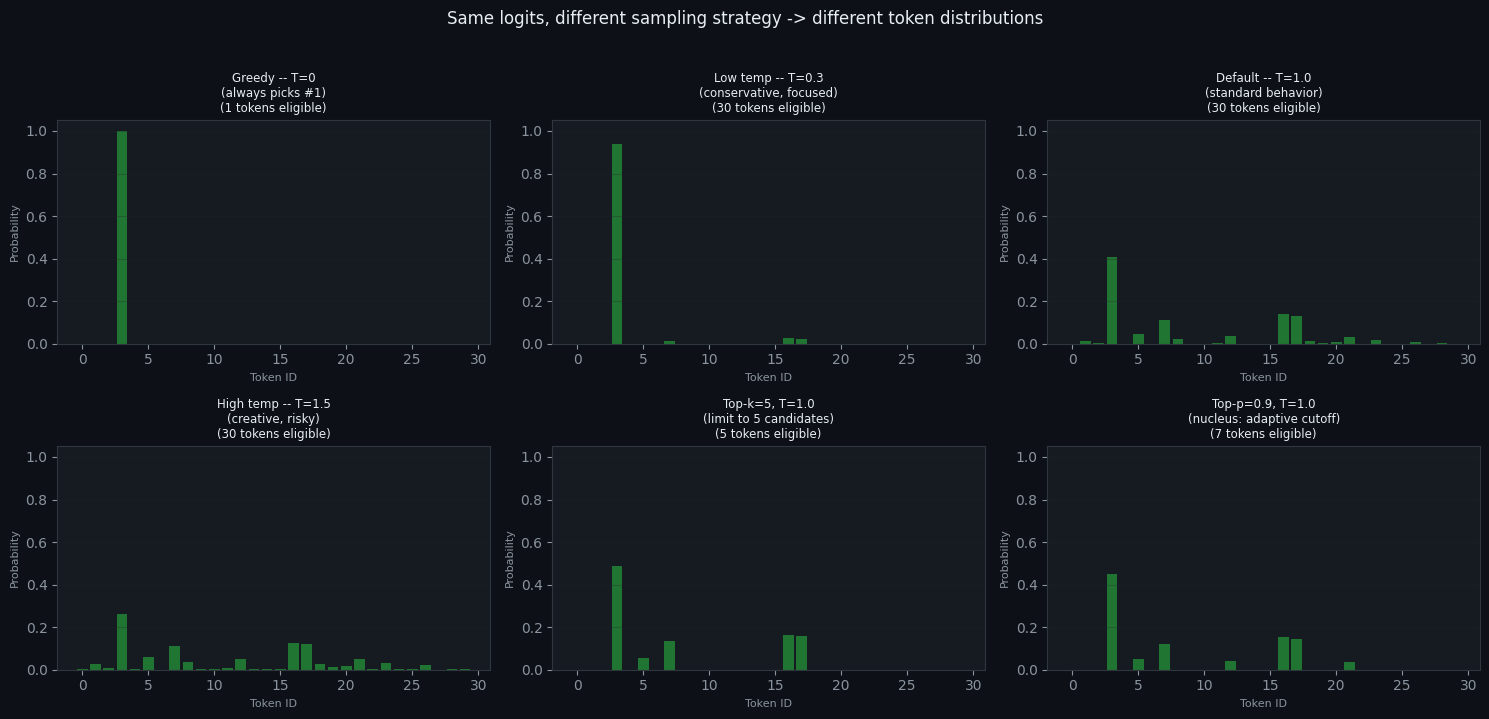

Observation: Top-k and Top-p reduce the number of green eligible tokens.
This prevents the model from accidentally sampling very low-probability garbage tokens.


In [22]:
# The full token sampling pipeline -- what inference engines do at the end of every decode step

def softmax_with_temperature(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    """Apply temperature scaling then convert to probabilities."""
    if temperature == 0:                        # greedy: argmax, deterministic
        probs = np.zeros_like(logits, dtype=float)
        probs[np.argmax(logits)] = 1.0
        return probs
    scaled = logits / temperature               # divide before softmax -- controls sharpness
    exp_s  = np.exp(scaled - scaled.max())      # stable softmax (subtract max prevents overflow)
    return exp_s / exp_s.sum()

def top_k_filter(probs: np.ndarray, k: int) -> np.ndarray:
    """Keep only the top-k tokens, zero out the rest, renormalize."""
    if k <= 0 or k >= len(probs):
        return probs
    threshold = np.sort(probs)[-k]
    filtered  = np.where(probs >= threshold, probs, 0.0)
    return filtered / filtered.sum()

def top_p_filter(probs: np.ndarray, p: float) -> np.ndarray:
    """Keep the smallest set of tokens whose cumulative probability >= p (nucleus sampling)."""
    sorted_idx = np.argsort(probs)[::-1]
    cumsum     = np.cumsum(probs[sorted_idx])
    cutoff     = np.searchsorted(cumsum, p) + 1
    keep       = sorted_idx[:cutoff]
    filtered   = np.zeros_like(probs)
    filtered[keep] = probs[keep]
    return filtered / filtered.sum()

def sample_token(logits, temperature=1.0, top_k=0, top_p=1.0) -> int:
    """Full pipeline: temperature -> top-k -> top-p -> sample"""
    probs = softmax_with_temperature(logits, temperature)
    probs = top_k_filter(probs, top_k)
    probs = top_p_filter(probs, top_p)
    return int(np.random.choice(len(probs), p=probs))

# Create realistic logits: a few high-scoring tokens, long tail of low-scoring ones
np.random.seed(123)
VOCAB_SIZE = 30
raw_logits = np.random.randn(VOCAB_SIZE) * 2
raw_logits[3]  = 5.5   # most likely token
raw_logits[7]  = 4.2   # second most likely
raw_logits[12] = 3.1   # third

STRATEGIES = [
    ("Greedy -- T=0\n(always picks #1)",               dict(temperature=0,    top_k=0, top_p=1.0)),
    ("Low temp -- T=0.3\n(conservative, focused)",     dict(temperature=0.3,  top_k=0, top_p=1.0)),
    ("Default -- T=1.0\n(standard behavior)",          dict(temperature=1.0,  top_k=0, top_p=1.0)),
    ("High temp -- T=1.5\n(creative, risky)",          dict(temperature=1.5,  top_k=0, top_p=1.0)),
    ("Top-k=5, T=1.0\n(limit to 5 candidates)",       dict(temperature=1.0,  top_k=5, top_p=1.0)),
    ("Top-p=0.9, T=1.0\n(nucleus: adaptive cutoff)",  dict(temperature=1.0,  top_k=0, top_p=0.9)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (name, kwargs) in zip(axes.flatten(), STRATEGIES):
    probs = softmax_with_temperature(raw_logits, kwargs["temperature"])
    probs = top_k_filter(probs, kwargs["top_k"])
    probs = top_p_filter(probs, kwargs["top_p"])
    n_active = (probs > 0).sum()
    colors = ["#238636" if p > 0 else "#21262d" for p in probs]
    ax.bar(range(VOCAB_SIZE), probs, color=colors, alpha=0.85)
    ax.set_title(f"{name}\n({n_active} tokens eligible)", color="#e6edf3", fontsize=8.5)
    ax.set_xlabel("Token ID", color="#8b949e", fontsize=8)
    ax.set_ylabel("Probability", color="#8b949e", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Same logits, different sampling strategy -> different token distributions",
             color="#e6edf3", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("Observation: Top-k and Top-p reduce the number of green eligible tokens.")
print("This prevents the model from accidentally sampling very low-probability garbage tokens.")

## Part 5: KV Cache Growth During Generation

Every decode step adds one more K and V entry to the cache. This has two costs:

1. **Memory grows** — like a log file that never rotates
2. **Each step gets slightly slower** — more keys to score against

The next cell measures both effects and shows where real GPU memory limits kick in.

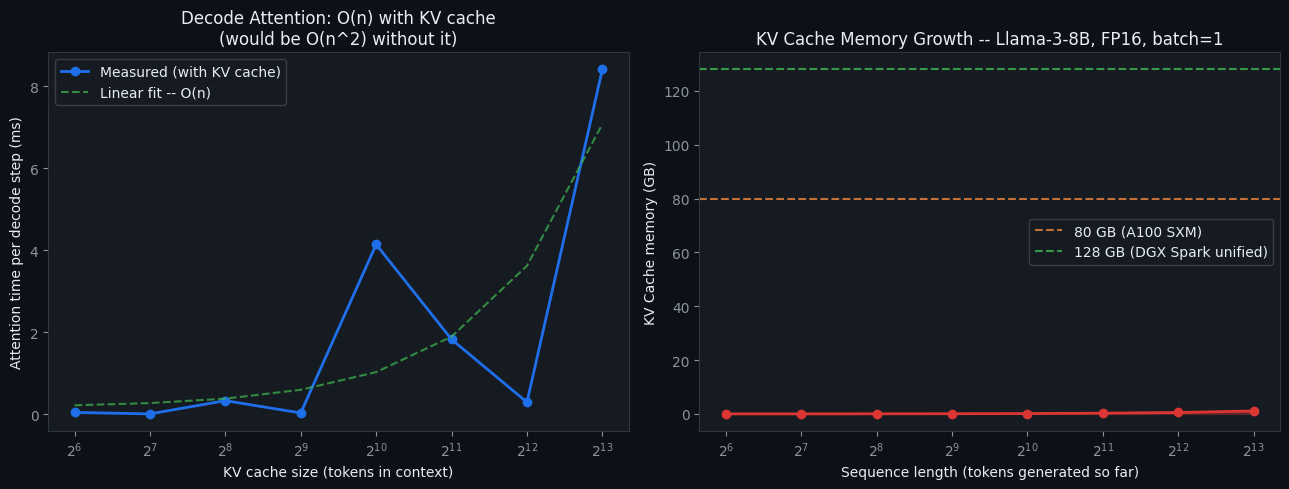

With KV cache: decode attention is LINEAR in context length O(n)
Without it:    each decode step would recompute ALL prior K,V -> O(n^2) quadratic

The KV cache trades memory for compute -- the classic cache trade-off.


In [23]:
# Measure how decode attention time scales with context length
# And visualize KV cache memory growth for a real model

def attention_time_vs_seqlen(seq_lengths, d_k=128, n_trials=3):
    """Time a single decode step (one query, N keys) as context grows."""
    times = []
    for seq_len in seq_lengths:
        trial_times = []
        for _ in range(n_trials):
            Q = np.random.randn(1, d_k)          # only 1 query (the new token)
            K = np.random.randn(seq_len, d_k)    # all keys from KV cache
            V = np.random.randn(seq_len, d_k)    # all values from KV cache

            t0 = time.perf_counter()
            # This is the actual decode attention operation:
            scores  = Q @ K.T / math.sqrt(d_k)  # similarity: new token vs all past tokens
            def softmax(x): e = np.exp(x - x.max()); return e / e.sum()
            weights = softmax(scores.flatten())
            output  = weights @ V                # weighted sum: what to pull from past context
            trial_times.append((time.perf_counter() - t0) * 1000)
        times.append(np.mean(trial_times))
    return times

seq_lengths = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
attn_times  = attention_time_vs_seqlen(seq_lengths)
kv_mems_gb  = [kv_cache_memory_gb(num_layers=32, num_kv_heads=8, head_dim=128, seq_len=s)
               for s in seq_lengths]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(seq_lengths, attn_times, "o-", color="#1f6feb", lw=2, markersize=6,
         label="Measured (with KV cache)")
coeffs = np.polyfit(seq_lengths, attn_times, 1)
ax1.plot(seq_lengths, np.poly1d(coeffs)(seq_lengths), "--", color="#3fb950", alpha=0.7,
         label="Linear fit -- O(n)")
ax1.set_xlabel("KV cache size (tokens in context)", color="#e6edf3")
ax1.set_ylabel("Attention time per decode step (ms)", color="#e6edf3")
ax1.set_title("Decode Attention: O(n) with KV cache\n(would be O(n^2) without it)", color="#e6edf3")
ax1.legend(framealpha=0.2)
ax1.grid(alpha=0.3)
ax1.set_xscale("log", base=2)

ax2.fill_between(seq_lengths, kv_mems_gb, alpha=0.35, color="#da3633")
ax2.plot(seq_lengths, kv_mems_gb, "o-", color="#da3633", lw=2, markersize=6)
ax2.axhline(80,  color="#f0883e", ls="--", alpha=0.8, label="80 GB (A100 SXM)")
ax2.axhline(128, color="#3fb950", ls="--", alpha=0.8, label="128 GB (DGX Spark unified)")
ax2.set_xlabel("Sequence length (tokens generated so far)", color="#e6edf3")
ax2.set_ylabel("KV Cache memory (GB)", color="#e6edf3")
ax2.set_title("KV Cache Memory Growth -- Llama-3-8B, FP16, batch=1", color="#e6edf3")
ax2.legend(framealpha=0.2)
ax2.grid(alpha=0.3)
ax2.set_xscale("log", base=2)

plt.tight_layout()
plt.show()
print("With KV cache: decode attention is LINEAR in context length O(n)")
print("Without it:    each decode step would recompute ALL prior K,V -> O(n^2) quadratic")
print("\nThe KV cache trades memory for compute -- the classic cache trade-off.")

## Part 6: Hands-On — Run Real GPT-2 and Measure the KV Cache Speedup

Everything above was simulation. Now we use real GPT-2 from HuggingFace
to empirically verify the KV cache speedup — the same experiments from the
[DeepLearning.AI \"Efficiently Serving LLMs\" course](https://www.deeplearning.ai/short-courses/efficiently-serving-llms/).

GPT-2 is small enough (124M params, ~500 MB) to run on CPU,
so this works on the controller node too. On a DGX Spark GPU the speedups
will be even more dramatic.

In [24]:
# Load GPT-2 from HuggingFace -- downloads once, cached locally after that
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch, time
import numpy as np
import matplotlib.pyplot as plt

MODEL_NAME = "gpt2"   # 124M params, ~500 MB -- smallest GPT-2 variant
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval()   # disable dropout -- deterministic outputs for experiments

print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens")
print(f"Context window:  {model.config.n_positions} tokens")
print(f"Layers:          {model.config.n_layer}")
print(f"Attention heads: {model.config.n_head}")
print(f"\nModel architecture (each block = one transformer layer):")
print(model)

/home/nvidia/src/github.com/elizabetht/100-days-of-inference/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11014.92it/s]

Model: gpt2
Parameters: 124M
Vocabulary size: 50,257 tokens
Context window:  1024 tokens
Layers:          12
Attention heads: 12

Model architecture (each block = one transformer layer):
GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln

### Experiment 1: One Forward Pass — Logits to Next Token

This is the atomic unit of LLM inference. Everything else is just repeating this.

**What we are doing:**
- Feed the prompt through the model once
- Get back 50,257 logit scores (one per token in GPT-2’s vocabulary)
- Pick the highest-scoring token (greedy decode)
- Inspect the top-10 candidates to see the model’s confidence

In [25]:
prompt = "The quick brown fox jumped over the"
inputs = tokenizer(prompt, return_tensors="pt")   # convert text -> tensors

print(f"Prompt:    '{prompt}'")
print(f"Input IDs: {inputs['input_ids'].tolist()[0]}")
print(f"Sequence length: {inputs['input_ids'].shape[1]} tokens")

with torch.no_grad():       # no_grad = do not track gradients (we are not training)
    outputs = model(**inputs)

logits = outputs.logits
print(f"\nOutput logits shape: {list(logits.shape)}")
print(f"  = [batch_size=1, seq_len={logits.shape[1]}, vocab_size={logits.shape[2]:,}]")
print(f"  -> {logits.shape[2]:,} scores, one per possible next token")

# Greedy decode: pick the highest-scoring token at the last position
last_logits   = logits[0, -1, :]          # shape: [vocab_size]
next_token_id = last_logits.argmax()
print(f"\nGreedy next token: {repr(tokenizer.decode(next_token_id))}")

# Top-10: inspect the model's confidence distribution
top_k = torch.topk(last_logits, k=10)
print(f"\nTop-10 candidates (raw logit scores):")
print(f"  {'Token':20s}  {'Logit':>8s}")
print(f"  {'-'*20}  {'-'*8}")
for score, tid in zip(top_k.values, top_k.indices):
    print(f"  {repr(tokenizer.decode(tid)):20s}  {score:8.2f}")

print("\nNote: logits are raw scores -- no constraint on magnitude or sign.")
print("The gap between the top score and others shows model confidence.")

Prompt:    'The quick brown fox jumped over the'
Input IDs: [464, 2068, 7586, 21831, 11687, 625, 262]
Sequence length: 7 tokens

Output logits shape: [1, 7, 50257]
  = [batch_size=1, seq_len=7, vocab_size=50,257]
  -> 50,257 scores, one per possible next token

Greedy next token: ' fence'

Top-10 candidates (raw logit scores):
  Token                    Logit
  --------------------  --------
  ' fence'                -81.90
  ' edge'                 -82.40
  ' railing'              -82.97
  ' wall'                 -83.07
  ' table'                -83.25
  ' tree'                 -83.52
  ' top'                  -83.55
  ' counter'              -83.81
  ' ground'               -83.88
  ' side'                 -83.88

Note: logits are raw scores -- no constraint on magnitude or sign.
The gap between the top score and others shows model confidence.


### Experiment 2: Generation Loop Without KV Cache

The naive approach: at every decode step, feed the **full growing sequence** back into the model.
Token 1: feed 8 tokens. Token 2: feed 9. Token 3: feed 10. And so on.

This is like a database query that re-scans the entire table every time you add a row.
Watch how per-step latency **grows** with each token.

In [26]:
def generate_token_no_cache(inputs):
    """One decode step -- no caching. Feeds the entire sequence every time."""
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.logits[0, -1, :].argmax()   # greedy: pick top-1 token

N_TOKENS = 10
next_inputs      = tokenizer(prompt, return_tensors="pt")
generated_tokens = []
durations_no_cache = []

print("Generating WITHOUT KV cache (naive -- full sequence re-processed each step):")
for step in range(N_TOKENS):
    t0 = time.perf_counter()
    next_token_id = generate_token_no_cache(next_inputs)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    durations_no_cache.append(elapsed_ms)

    # Append new token to the sequence for next iteration
    next_inputs = {
        "input_ids": torch.cat(
            [next_inputs["input_ids"], next_token_id.reshape(1, 1)], dim=1),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])], dim=1),
    }
    token_str = tokenizer.decode(next_token_id)
    generated_tokens.append(token_str)
    seq_len = next_inputs["input_ids"].shape[1]
    print(f"  Step {step+1:2d}: '{token_str:12s}'  seq_len={seq_len:3d}  time={elapsed_ms:.1f}ms")

print(f"\nTotal: {sum(durations_no_cache):.1f}ms for {N_TOKENS} tokens")
print(f"Output: '{''.join(generated_tokens)}'")

Generating WITHOUT KV cache (naive -- full sequence re-processed each step):
  Step  1: ' fence      '  seq_len=  8  time=72.0ms
  Step  2: ' and        '  seq_len=  9  time=68.4ms
  Step  3: ' ran        '  seq_len= 10  time=63.4ms
  Step  4: ' to         '  seq_len= 11  time=65.4ms
  Step  5: ' the        '  seq_len= 12  time=96.4ms
  Step  6: ' other      '  seq_len= 13  time=95.6ms
  Step  7: ' side       '  seq_len= 14  time=101.7ms
  Step  8: ' of         '  seq_len= 15  time=100.1ms
  Step  9: ' the        '  seq_len= 16  time=104.9ms
  Step 10: ' fence      '  seq_len= 17  time=104.0ms

Total: 872.0ms for 10 tokens
Output: ' fence and ran to the other side of the fence'


### Experiment 3: Generation Loop With KV Cache

Now the same loop, but on each step:
- Pass **only the new token** as `input_ids` (1 token instead of N)
- Pass `past_key_values` from the previous step (the cached K and V tensors)

The model reuses all previously computed K/V tensors — it only needs to compute
attention between the new token and the cached keys.

Watch how per-step latency **stays flat** after the first step.

In [28]:
def generate_token_with_cache(inputs):
    """One decode step -- returns new token + updated KV cache."""
    with torch.no_grad():
        outputs = model(**inputs)
    next_token_id   = outputs.logits[0, -1, :].argmax()
    past_key_values = outputs.past_key_values    # the KV cache to reuse
    return next_token_id, past_key_values

next_inputs         = tokenizer(prompt, return_tensors="pt")
generated_tokens_kv = []
durations_cached    = []

print("Generating WITH KV cache (only new token fed each step):")
for step in range(N_TOKENS):
    t0 = time.perf_counter()
    next_token_id, past_key_values = generate_token_with_cache(next_inputs)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    durations_cached.append(elapsed_ms)

    # Next step: only pass the single new token + the cache
    next_inputs = {
        "input_ids":       next_token_id.reshape(1, 1),    # only 1 token
        "attention_mask":  torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])], dim=1),
        "past_key_values": past_key_values,                # cached K/V tensors
    }
    token_str = tokenizer.decode(next_token_id)
    generated_tokens_kv.append(token_str)
    cache_len = past_key_values[0][0].shape[2]             # tokens in cache
    print(f"  Step {step+1:2d}: '{token_str:12s}'  cache_len={cache_len:3d}  time={elapsed_ms:.1f}ms")

print(f"\nTotal: {sum(durations_cached):.1f}ms for {N_TOKENS} tokens")
print(f"Output: '{''.join(generated_tokens_kv)}'")

# Correctness check -- both approaches must produce identical tokens
assert generated_tokens == generated_tokens_kv, f"Mismatch! {generated_tokens} vs {generated_tokens_kv}"
print("\nOutputs are identical -- KV cache is a pure optimization, not an approximation.")

Generating WITH KV cache (only new token fed each step):


TypeError: 'DynamicCache' object is not subscriptable

### Experiment 4: Visualize and Quantify the Speedup

The plots below show what you expect after understanding the KV cache:

- **No KV cache (red):** per-step latency grows — each step processes more tokens
- **KV cache (blue):** per-step latency is flat after the first step — constant-time decode

The speedup grows with output length. On 1000-token outputs, the gap is enormous.

In [ ]:
steps = list(range(1, N_TOKENS + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(steps, durations_no_cache, "o-", color="#da3633", lw=2, markersize=7,
         label="No KV cache (full sequence every step)")
ax1.plot(steps, durations_cached,   "s-", color="#1f6feb", lw=2, markersize=7,
         label="With KV cache (1 token per step after prefill)")
ax1.set_xlabel("Decode step", color="#e6edf3")
ax1.set_ylabel("Latency (ms)", color="#e6edf3")
ax1.set_title("Per-Step Decode Latency\nRed grows, blue stays flat", color="#e6edf3")
ax1.legend(framealpha=0.2)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(steps)

ax2.plot(steps, np.cumsum(durations_no_cache), "o-", color="#da3633", lw=2, markersize=7,
         label="No KV cache")
ax2.plot(steps, np.cumsum(durations_cached),   "s-", color="#1f6feb", lw=2, markersize=7,
         label="With KV cache")
ax2.set_xlabel("Decode step", color="#e6edf3")
ax2.set_ylabel("Cumulative latency (ms)", color="#e6edf3")
ax2.set_title("Cumulative Latency\nGap widens with more tokens", color="#e6edf3")
ax2.legend(framealpha=0.2)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(steps)

total_no_cache = sum(durations_no_cache)
total_cached   = sum(durations_cached)
speedup        = total_no_cache / total_cached
fig.suptitle(
    f"KV Cache Speedup: {speedup:.2f}x  "
    f"({total_no_cache:.0f}ms -> {total_cached:.0f}ms for {N_TOKENS} tokens)\n"
    f"Speedup grows with sequence length -- on 1000-token outputs it could be 10-100x",
    fontsize=11, fontweight="bold", color="#e6edf3", y=1.03
)
plt.tight_layout()
plt.show()

print(f"No KV cache:   {total_no_cache:.1f} ms total ({total_no_cache/N_TOKENS:.1f} ms/token avg)")
print(f"With KV cache: {total_cached:.1f} ms total ({total_cached/N_TOKENS:.1f} ms/token avg)")
print(f"Speedup:       {speedup:.2f}x on {N_TOKENS} tokens -- grows significantly on longer outputs")
print(f"\nOn 1000-token outputs, the naive approach is ~500-1000x slower.")
print(f"This is why every production LLM inference stack uses KV caching by default.")

## Exercises — Go Deeper

These are good follow-on experiments to build more intuition:

1. **Temperature sweep**: Loop through `temperature` values `[0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]`.
   For each, compute the **entropy** of the resulting probability distribution (`-sum(p * log(p))`).
   Plot entropy vs temperature. What does the curve tell you about controllability?

2. **KV cache sizing for your workload**: Pick a model from the MODELS dict and a target batch size
   (e.g., 32 concurrent requests). Calculate total GPU memory needed (model weights + KV cache
   for all concurrent requests at your expected sequence length). Compare against the
   128 GB unified memory on the DGX Spark.

3. **Longer generation**: Increase `N_TOKENS` to 50 or 100 in the GPT-2 experiments above.
   Plot the per-step latency curves. Does the no-cache line grow linearly or super-linearly?
   At what output length does the KV cache version become 10x faster?

## Key Takeaways

If you only remember six things from Day 01:

**1. LLMs generate one token at a time** — this is a fundamental constraint, not an implementation detail.
Each output token requires a full GPU forward pass. There is no way to parallelize across output tokens.

**2. Tokens are the unit of work** — everything in inference (latency, memory, cost) scales with token count.
A more efficient tokenizer is free performance.

**3. Prefill is compute-bound, decode is memory-bound** — they stress different parts of the hardware.
This is why inference needs both high FLOPS *and* high memory bandwidth.

**4. The KV cache is the #1 optimization** — it trades GPU memory for compute, reducing decode from
O(n²) to O(n). Every production system uses it. Understanding KV cache sizing is core to capacity planning.

**5. Sampling controls output quality** — temperature, top-k, and top-p are the knobs.
Lower temperature = more deterministic. These are inference-time parameters, not model parameters.

**6. TTFT and TPOT are the two metrics that matter** — Time To First Token (prefill latency) and
Time Per Output Token (decode latency). Every optimization in this curriculum targets one or both.

## References

- *Inference Engineering* Ch 2.2 (pp. 46–54) — Philip Kiely, Baseten Books 2026
- Vaswani et al., \"Attention Is All You Need\" (2017)
- Dao et al., \"FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness\" (2022)
- DeepLearning.AI, \"Efficiently Serving LLMs\" short course